In [ ]:
import csv
import numpy as np

tr_in = np.genfromtxt('train_in.csv', delimiter=",")
tr_out = np.genfromtxt('train_out.csv', delimiter=",")
te_in = np.genfromtxt('test_in.csv', delimiter=",")
te_out = np.genfromtxt('test_out.csv', delimiter=",")

#a digit for every possible digit
digits = [[] for x in range(10)]
#for every possible digit a vector with 256 values, one for each pixel. For each handwritten digit, we want to find the mean of each pixel
centers = [np.empty(256) for x in range(10)]

#divide the rows (each has 256 values) of the training set based on the labels. So that digits[x] has all the rows corresponding to images representing that number
posit=0
for row in tr_in:
    digit=int(tr_out[posit])
    digits[digit].append(row)
    posit+=1

#calculating the mean for each pixel. We will have Mean of 0: 256 values; Mean of 1: 256 values... and so on.
for x in range(10):
    centers[x]=np.mean(digits[x], axis=0)

In [ ]:
#foreseeing labels

#an array as big as the testing set. Here we will put the predicted labels
label=np.empty(len(te_in), dtype="int")
distances=np.empty(10)


img=0
for image in te_in:
    x=0
    #we compare every image with every mean.
    for mean in centers:
        #For every image, we see the distance between it and the 10 means. linalgnorm is basically no more than the theorem of Pytagoras applied to more than 2 dimensions
        distances[x]=np.linalg.norm(image-mean)
        x+=1
    #we find the shortest distance between the image and the means. This tells us the prediction
    label[img]=np.argmin(distances)
    img+=1

print(label)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 8 5 5 4 0 9 2 4 6 0 9 8 0 0 6 4 0 6 6 8 0 2
 2 0 0 0 0 8 8 6 6 0 9 0 9 0 2 0 2 2 1 2 1 6 1 2 1 5 1 6 1 8 3 6 0 4 8 4 0
 0 1 8 4 3 0 4 6 0 1 2 6 6 6 3 4 0 0 6 8 2 0 1 9 9 9 9 6 6 7 7 7 7 9 9 7 6
 8 2 7 6 8 1 0 1 1 1 6 7 6 8 0 1 9 8 1 8 6 8 0 8 4 0 0 0 4 4 1 3 1 6 4 1 4
 1 9 6 5 2 4 1 0 0 0 1 1 0 0 1 8 1 0 0 0 7 1 0 0 1 7 1 6 0 2 0 1 8 9 4 1 0
 1 0 8 1 0 1 0 1 1 0 0 0 1 1 0 1 6 3 1 0 0 2 2 1 0 0 2 1 1 0 6 5 4 1 8 0 1
 0 1 0 0 0 3 1 0 0 3 0 8 9 1 6 9 8 9 1 6 8 8 0 3 6 8 5 7 1 1 7 0 2 8 8 7 0
 4 9 5 0 2 8 8 9 1 6 9 2 0 7 7 0 0 8 9 9 0 7 5 9 7 9 0 1 9 6 5 4 4 0 0 4 9
 4 8 8 8 3 4 0 1 6 0 1 2 7 3 4 4 6 1 1 7 5 1 3 3 3 3 0 9 1 6 3 7 8 0 0 7 8
 4 1 1 4 9 0 8 7 9 4 6 1 8 9 4 2 4 0 0 0 0 3 7 6 2 3 1 7 0 0 0 6 4 5 6 6 8
 4 8 1 9 0 4 3 6 1 2 4 3 8 1 4 1 4 2 6 0 7 6 8 1 3 9 0 0 2 5 3 5 0 4 4 1 4
 2 1 9 3 5 0 5 6 0 9 8 8 1 9 7 1 4 2 3 2 3 1 8 3 3 6 0 2 3 2 6 0 2 5 6 6 1
 2 0 4 3 9 6 5 0 1 4 4 4 3 4 2 0 0 0 5 8 1 0 2 2 0 6 8 5 2 0 0 1 3 2 6 4 6
 0 0 0 0 1 6 7 9 9 6 6 2 

In [ ]:
#Calculating distances between 10 centers

dist_bt_centers = np.ones((len(centers), len(centers)))

x=0
y=0
#for every center (mean) we find the distance between them with the same method as above.
for cent in centers:
    for cent in centers:
        dist_bt_centers[x, y] = np.linalg.norm(centers[x]-centers[y])
        y+=1
    else:
        y=0
    x+=1

round_dist = np.round(dist_bt_centers, decimals=2)
print(round_dist)

#the output says us what's the distance between the number represented by the row and the number represented by the column (it's symmetrical).
#we can say the most difficult digits to separate are the closest ones.

[[ 0.   14.45  9.33  9.14 10.77  7.52  8.15 11.86  9.91 11.49]
 [14.45  0.   10.13 11.73 10.17 11.12 10.61 10.74 10.09  9.93]
 [ 9.33 10.13  0.    8.18  7.93  7.91  7.33  8.87  7.08  8.89]
 [ 9.14 11.73  8.18  0.    9.09  6.12  9.3   8.92  7.02  8.35]
 [10.77 10.17  7.93  9.09  0.    8.    8.78  7.58  7.38  6.01]
 [ 7.52 11.12  7.91  6.12  8.    0.    6.7   9.21  6.97  8.26]
 [ 8.15 10.61  7.33  9.3   8.78  6.7   0.   10.89  8.59 10.44]
 [11.86 10.74  8.87  8.92  7.58  9.21 10.89  0.    8.47  5.43]
 [ 9.91 10.09  7.08  7.02  7.38  6.97  8.59  8.47  0.    6.4 ]
 [11.49  9.93  8.89  8.35  6.01  8.26 10.44  5.43  6.4   0.  ]]


The most difficult digits to separate are: 7 and 9 (dist: 5.43); 4 and 9 (dist: 6.01); 3 and 5 (dist: 6.12).

In [ ]:
#dimensionality reduction algorithms: PCA

from sklearn.decomposition import PCA

#I just applied this dimensionality reduction algorithm so that instead of 256 values for every image we have 2 values.
pca=PCA(n_components=2)
pca_data=pca.fit_transform(tr_in)

pcadigits = [[] for x in range(len(digits))]

#this is the same as above to have the new values divided per every digit.
posit=0
for row in pca_data:
    digit=int(tr_out[posit])
    pcadigits[digit].append(row)
    posit+=1

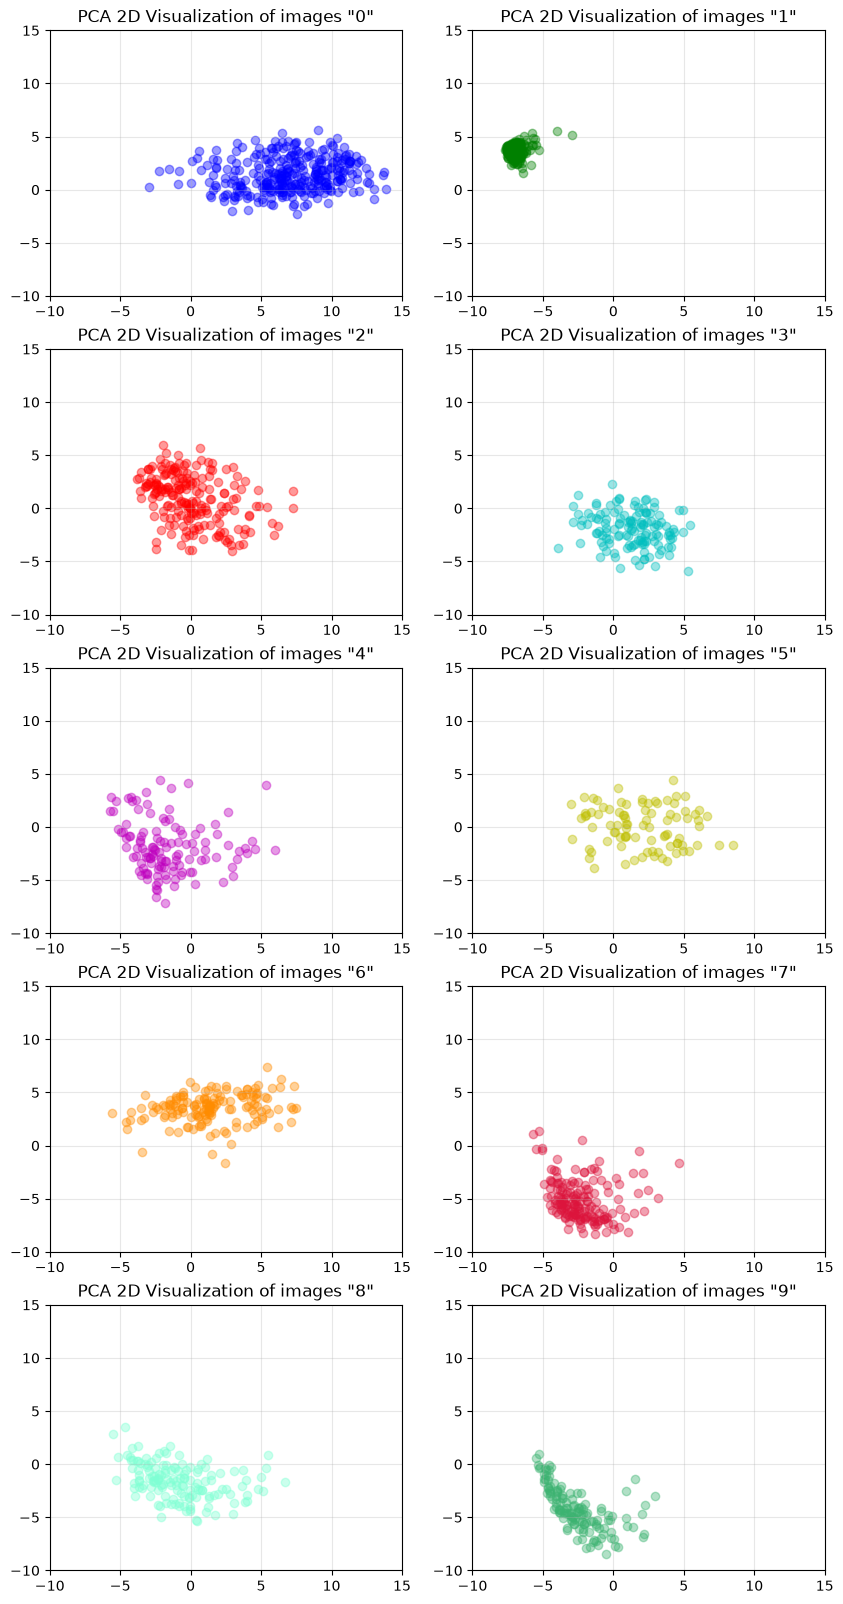

In [7]:
#visualising PCA

import matplotlib.pyplot as plt

colors=["b","g","r","c","m","y","darkorange", "crimson", "aquamarine", "mediumseagreen"]

fig, ax=plt.subplots(5, 2, figsize=(10,20))

for dig in range(len(pcadigits)):
    digx=dig//2
    digy=dig%2
    ax[digx, digy].set_xlim(left=-10, right=15)
    ax[digx, digy].set_ylim(bottom=-10, top=15)
    X = [point[0] for point in pcadigits[dig]]
    Y = [point[1] for point in pcadigits[dig]]   
    ax[digx, digy].scatter(X, Y, c=colors[dig], alpha=0.4)  
    ax[digx, digy].set_title(f'PCA 2D Visualization of images "{dig}"')
    ax[digx, digy].grid(True, alpha=0.3)

In [ ]:
#dimensionality reduction algorithms: U-MAP

#same as above but is with umap
import umap
reducer=umap.UMAP()
umap_data=reducer.fit_transform(tr_in)

umapdigits = [[] for x in range(len(digits))]

posit=0
for row in umap_data:
    digit=int(tr_out[posit])
    umapdigits[digit].append(row)
    posit+=1

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


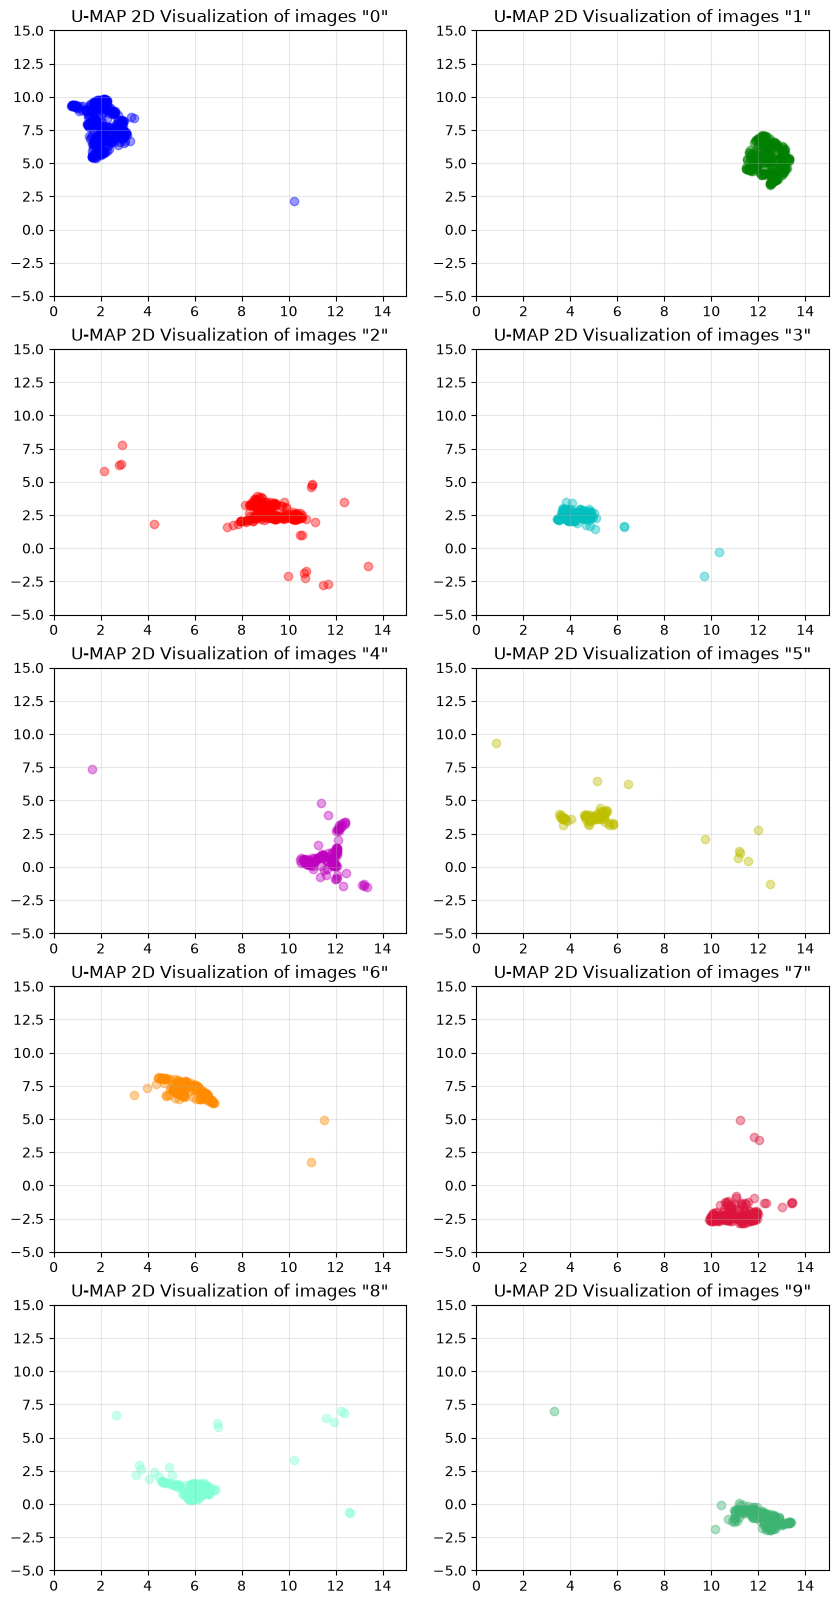

In [9]:
#visualising U-MAP

fig2, ax2=plt.subplots(5, 2, figsize=(10,20))

minX=[]
minY=[]
maxX=[]
maxY=[]
for dig in range(len(umapdigits)):
    digx=dig//2
    digy=dig%2
    ax2[digx, digy].set_xlim(left=0, right=15)
    ax2[digx, digy].set_ylim(bottom=-5, top=15)
    X = [point[0] for point in umapdigits[dig]]
    Y = [point[1] for point in umapdigits[dig]]
    # minX.append(min(X))
    # minY.append(min(Y))
    # maxX.append(max(X))
    # maxY.append(max(Y))
    ax2[digx, digy].scatter(X, Y, c=colors[dig], alpha=0.4)  
    ax2[digx, digy].set_title(f'U-MAP 2D Visualization of images "{dig}"')
    ax2[digx, digy].grid(True, alpha=0.3)
#print(f"minX: {min(minX)}, minY: {min(minY)}, maxX: {max(maxX)}, maxY: {max(maxY)}")

In [ ]:
#dimensionality reduction algorithms: t-SNE
from sklearn import manifold

#same as above but is t-sne
t_sne=manifold.TSNE()
tsne_data= t_sne.fit_transform(tr_in)

tsnedigits = [[] for x in range(len(digits))]

posit=0
for row in tsne_data:
    digit=int(tr_out[posit])
    tsnedigits[digit].append(row)
    posit+=1

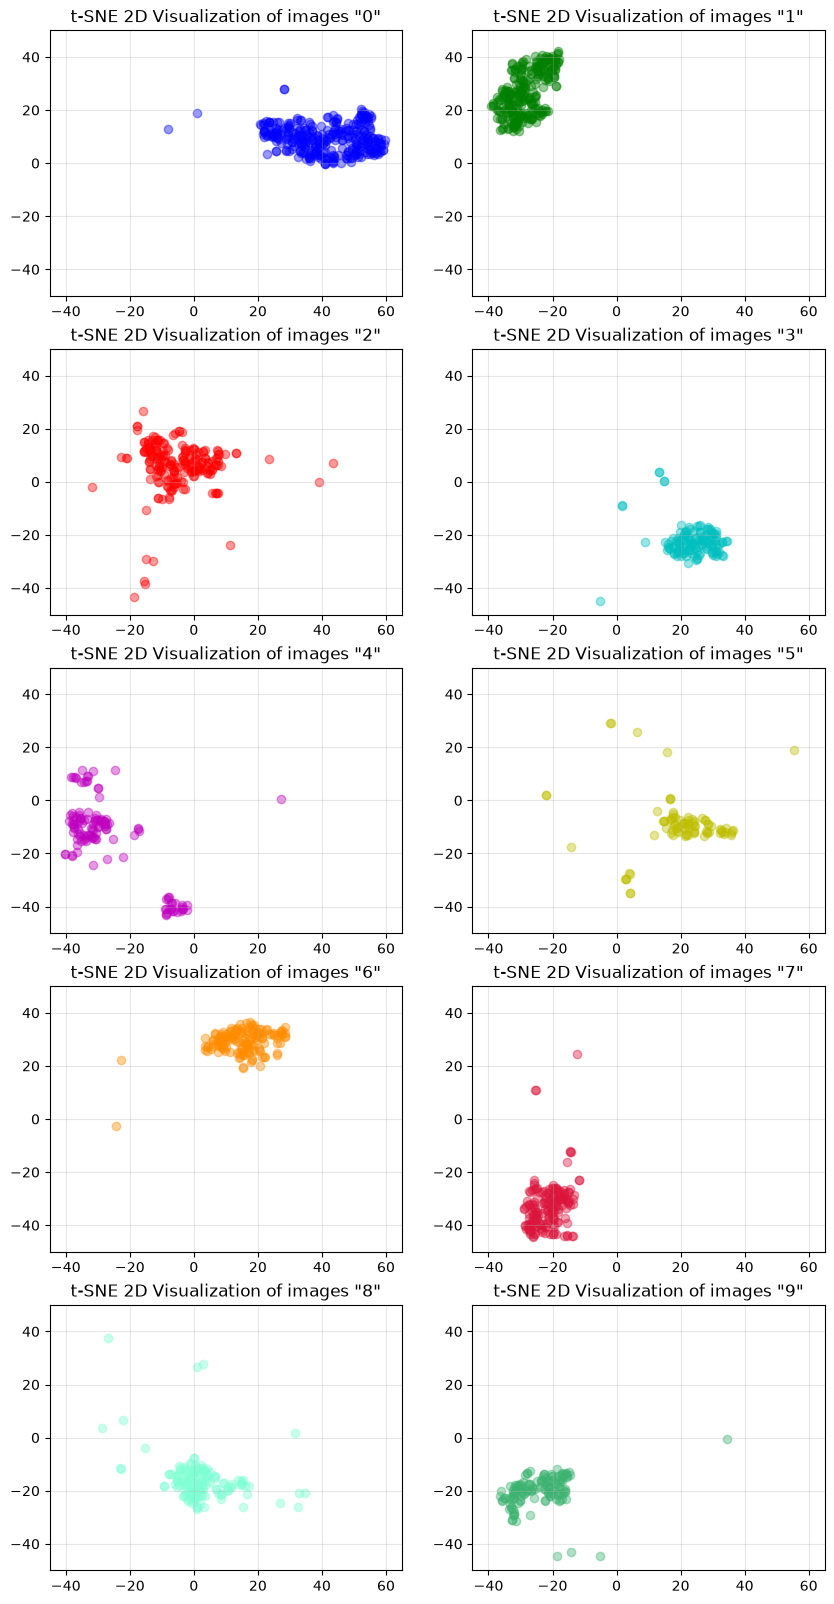

In [ ]:
#visualising t-SNE

fig3, ax3=plt.subplots(5, 2, figsize=(10,20))

# minX=[]
# minY=[]
# maxX=[]
# maxY=[]
for dig in range(len(tsnedigits)):
    digx=dig//2
    digy=dig%2
    ax3[digx, digy].set_xlim(left=-45, right=65)
    ax3[digx, digy].set_ylim(bottom=-50, top=50)
    X = [point[0] for point in tsnedigits[dig]]
    Y = [point[1] for point in tsnedigits[dig]]
    # minX.append(min(X))
    # minY.append(min(Y))
    # maxX.append(max(X))
    # maxY.append(max(Y))
    ax3[digx, digy].scatter(X, Y, c=colors[dig], alpha=0.4)  
    ax3[digx, digy].set_title(f't-SNE 2D Visualization of images "{dig}"')
    ax3[digx, digy].grid(True, alpha=0.3)
# print(f"minX: {min(minX)}, minY: {min(minY)}, maxX: {max(maxX)}, maxY: {max(maxY)}")

Yes, the visualization agrees with my intuitions and the distances presented by the matrix.

In [ ]:
#Nearest Mean Classifier

#the function version of what we did above: for every dataset of images, it tells the closest mean digit. That's how if finds the predicted label. 
def nmf(x):
    labels=np.empty(len(x), dtype="int")
    distances=np.empty(10)

    img=0
    for image in x:
        i=0
        for mean in centers:
            distances[i]=np.linalg.norm(image-mean)
            i+=1
        labels[img]=np.argmin(distances)
        img+=1

    return labels

#to calculate how many of the predicted digits are correct (i compare them with the correct ones)
def rightpercent(x, y):
    correct=0
    for i in range(len(x)):
        if x[i]==y[i]:
            correct+=1
    
    percent=correct*100/len(x)
    return percent

tr_cor=rightpercent(nmf(tr_in), tr_out)
print(f"The Nearest Mean Classifier correctly calculates {tr_cor:.2f}% of the training set")

te_cor=rightpercent(nmf(te_in), te_out)
print(f"The Nearest Mean Classifier correctly calculates {te_cor:.2f}% of the testing set")

The Nearest Mean Classifier correctly calculates 86.35% of the training set
The Nearest Mean Classifier correctly calculates 80.40% of the testing set


In [ ]:
#KNN

#another method based on the analysis of the closest neighbours of every image. in this case the number of neighbours i set is 5. we can also try with different values there.

from sklearn.neighbors import KNeighborsClassifier

def knn(tr, lab, te):
    neigh=KNeighborsClassifier(n_neighbors=5)
    neigh.fit(tr, lab)

    return neigh.predict(te)

pred_tr=knn(tr_in, tr_out, tr_in)
knn_tr_cor=rightpercent(pred_tr, tr_out)
print(f"The K-Nearest-Neighbor correctly calculates {knn_tr_cor:.2f}% of the training set")

pred_te=knn(tr_in, tr_out, te_in)
knn_te_cor=rightpercent(pred_te, te_out)
print(f"The K-Nearest-Neighbor correctly calculates {knn_te_cor:.2f}% of the testing set")



The K-Nearest-Neighbor correctly calculates 96.60% of the training set
The K-Nearest-Neighbor correctly calculates 90.80% of the testing set


In [ ]:
#nmf confusion matrix

from sklearn.metrics import confusion_matrix

#this is to visualise the confusion matrix as a percent
def percents_cm(matrix):

    output=np.empty(np.shape(matrix))
    sum=[0,0,0,0,0,0,0,0,0,0]
    for row in range(len(matrix)):
        for i in matrix[row]:
            sum[row]+=i
        output[row]=np.round(np.divide(matrix[row]*100, sum[row]), decimals=2)
    return output 
    


#confusion matrix: how many times an image with the number representing the row was predicted as the number representing the column?
nmf_trcounts_cm=confusion_matrix(nmf(tr_in), tr_out)

nmf_trpercents_cm=percents_cm(nmf_trcounts_cm)

nmf_tecounts_cm=confusion_matrix(nmf(te_in), te_out)

nmf_tepercents_cm=percents_cm(nmf_tecounts_cm)

print(f"Confusion matrix describing the Nearest Mean Classifier on the training set:\n{nmf_trpercents_cm}")
print(f"\nConfusion matrix describing the Nearest Mean Classifier on the testing set:\n{nmf_tepercents_cm}")

Confusion matrix describing the Nearest Mean Classifier on the training set:
[[94.1   0.    1.04  0.    0.    1.04  3.47  0.    0.35  0.  ]
 [ 0.   92.31  0.    0.    2.93  0.    1.47  1.47  0.73  1.1 ]
 [ 0.    0.   93.82  1.12  0.56  1.12  2.81  0.    0.56  0.  ]
 [ 0.    0.    6.29 83.92  0.    2.1   0.    0.    6.99  0.7 ]
 [ 1.57  0.    7.09  0.79 74.8   3.15  1.57  1.57  1.57  7.87]
 [ 5.    0.    1.25  3.75  0.   83.75  0.    2.5   3.75  0.  ]
 [20.57  0.    1.71  0.    1.71  1.71 73.71  0.    0.57  0.  ]
 [ 0.    0.    2.63  0.66  0.    0.66  0.   92.11  0.    3.95]
 [ 4.29  0.    4.29  2.14  0.    1.43  0.71  0.71 86.43  0.  ]
 [ 0.    0.    0.    0.66  9.93  1.99  0.   11.26  1.99 74.17]]

Confusion matrix describing the Nearest Mean Classifier on the testing set:
[[90.36  0.    1.02  1.52  0.51  1.52  3.55  0.    1.52  0.  ]
 [ 0.   90.91  0.    0.    2.27  0.    0.    1.52  1.52  3.79]
 [ 3.7   0.   85.19  3.7   3.7   0.    2.47  1.23  0.    0.  ]
 [ 2.47  0.    7.41 75.31 

The least recognisable digits with the Nearest Mean Classifier in the training set are:
6 (only 73.71% correct guesses), often confused with 0 (20.57% wrong guesses);
9 (only 74.17% correct guesses), often confused with 7 (11.26% wrong guesses) and 4 (9.93% wrong guesses);
4 (only 74.8% correct guesses), often confused with 9 (7.87% wrong guesses) and 2 (7.09% wrong guesses);
The least recognisable digits in the testing set are:
4 (only 66.99% correct guesses), often confused with 9 (7.77% wrong guesses) and 2 (7.77% wrong guesses);
5 (only 71.7% correct guesses), often confused with 3 (15.09% wrong guesses).
8 (only 73.74% correct guesses), often confused with 2 (13.13% wrong guesses) and 0 (10.1% wrong guesses).

Overall, the performance in the testing set is worse than in the training set.

In [ ]:
#knn confusion matrix

#same but with knn instead of nearest mean classifier as a method for prediction
knn_trcounts_cm=confusion_matrix(knn(tr_in, tr_out, tr_in), tr_out)

knn_trpercents_cm=percents_cm(knn_trcounts_cm)

knn_tecounts_cm=confusion_matrix(knn(tr_in, tr_out, te_in), te_out)

knn_tepercents_cm=percents_cm(knn_tecounts_cm)

print(f"Confusion matrix describing the K-Nearest-Neighbor on the training set:\n{knn_trpercents_cm}")
print(f"\nConfusion matrix describing the K-Nearest-Neighbor on the testing set:\n{knn_tepercents_cm}")

Confusion matrix describing the K-Nearest-Neighbor on the training set:
[[ 96.66   0.     0.61   0.61   0.     0.91   0.3    0.     0.61   0.3 ]
 [  0.    94.38   1.5    0.     1.5    0.     0.37   1.12   1.12   0.  ]
 [  0.52   0.    98.44   0.     0.     0.52   0.52   0.     0.     0.  ]
 [  0.     0.     0.74  94.81   0.     0.74   0.     0.     3.7    0.  ]
 [  0.     0.     0.85   0.    96.61   0.85   0.     0.     1.69   0.  ]
 [  0.     0.     0.     0.     0.   100.     0.     0.     0.     0.  ]
 [  0.     0.     0.     0.     0.     0.67  99.33   0.     0.     0.  ]
 [  0.     0.     2.37   0.     0.     0.     0.    95.86   0.59   1.18]
 [  0.     0.     0.     0.77   0.     0.     0.     0.    99.23   0.  ]
 [  0.     0.     0.72   0.     2.9    0.72   0.     0.72   1.45  93.48]]

Confusion matrix describing the K-Nearest-Neighbor on the testing set:
[[90.5   0.    2.89  1.24  0.    2.89  1.24  0.    0.83  0.41]
 [ 0.   90.84  1.53  0.    1.53  0.76  0.76  3.05  1.53  0.  ]

The least recognisable digits with the K-Nearest-Neighbor in the training set are:
9 (93.48% correct guesses);
1 (94.38% correct guesses);
3 (94.81% correct guesses).

The least recognisable digits with the K-Nearest-Neighbor in the testing set are:
3 (82.35% correct guesses), often confused with 5 (9.41% wrong guesses);
7 (86.15% correct guesses), often confused with 9 (6.15% wrong guesses) and 2 (4.62% wrong guesses);
9 (88.17% correct guesses).

Overall, the performance in the testing set is worse than in the training set.